# 03 Baseline Model - TF-IDF + Logistic Regression

This notebook builds the first baseline model,We treat the task as **binary text classification**: classifying each health-related text as either reliable (`1`) or misinformation / unreliable (`0`).


## Why this model first?

We start with **TF-IDF + Logistic Regression** because it is fast, strong as a research baseline, easy to explain, and works very well in Jupyter Notebook. It lets us establish a clean benchmark before moving to heavier transformer models like **BioBERT** or **DistilBERT** later.


In [1]:
from pathlib import Path
import json

import joblib
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import FeatureUnion, Pipeline


In [2]:
PROJECT_ROOT = Path(r'C:\Users\ribam\Desktop\Reseach\Dataset')
DATA_PATH = PROJECT_ROOT / 'dataset' / 'processed' / 'fakehealth_healthfact_binary_clean.csv'
MODEL_DIR = PROJECT_ROOT / 'model'
OUTPUT_DIR = PROJECT_ROOT / 'output'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH


WindowsPath('C:/Users/ribam/Desktop/Reseach/Dataset/dataset/processed/fakehealth_healthfact_binary_clean.csv')

In [3]:
df = pd.read_csv(DATA_PATH)
TEXT_COL = "model_text" if "model_text" in df.columns else "text"
preview_cols = list(dict.fromkeys(["dataset", "split", "label_binary", "text", TEXT_COL]))

print("Shape:", df.shape)
print("Text column:", TEXT_COL)
df[preview_cols].head(3)


Shape: (12273, 16)
Text column: model_text


,dataset,split,label_binary,text,model_text
0,fakehealth,release,0,"MADISON, Wis. -- More than 700 million adults ...",Tiny implantable device short-circuits hunger ...
1,fakehealth,release,1,"Wilmington, DE, December 17, 2018 - The CRISPR...",Scientists report CRISPR restores effectivenes...
2,fakehealth,release,0,About 3 million people in the US are diagnosed...,Probiotics could help millions of patients suf...


## Split Strategy

Because `healthfact` already has `train/dev/test` splits while `FakeHealth` does not, we use a **hybrid split strategy**:

- keep `healthfact` original `train`, `dev`, and `test`
- split `FakeHealth` randomly into `train`, `dev`, and `test` with stratification by label
- combine those partitions into final train/dev/test sets


In [4]:
VALID_SPLITS = {"train", "dev", "test"}
CURATED_TRAIN_REPEAT = 4


def make_train_dev_test(data: pd.DataFrame, random_state: int = 42):
    # Respect existing train/dev/test splits and split unsplit datasets reproducibly.
    data = data.copy()
    data["split"] = data["split"].fillna("").astype(str).str.lower().str.strip()

    fixed = data[data["split"].isin(VALID_SPLITS)].copy()
    unsplit = data[~data["split"].isin(VALID_SPLITS)].copy()

    split_frames = {
        "train": [fixed[fixed["split"] == "train"]],
        "dev": [fixed[fixed["split"] == "dev"]],
        "test": [fixed[fixed["split"] == "test"]],
    }

    for dataset_name, group in unsplit.groupby("dataset"):
        group = group.copy()
        if len(group) < 10 or group["label"].nunique() < 2:
            group["split"] = "train"
            split_frames["train"].append(group)
            continue

        train_part, temp_part = train_test_split(
            group,
            test_size=0.30,
            stratify=group["label"],
            random_state=random_state,
        )
        dev_part, test_part = train_test_split(
            temp_part,
            test_size=0.50,
            stratify=temp_part["label"],
            random_state=random_state,
        )
        train_part = train_part.copy()
        dev_part = dev_part.copy()
        test_part = test_part.copy()
        train_part["split"] = "train"
        dev_part["split"] = "dev"
        test_part["split"] = "test"
        split_frames["train"].append(train_part)
        split_frames["dev"].append(dev_part)
        split_frames["test"].append(test_part)

    train_df = pd.concat(split_frames["train"], ignore_index=True)
    dev_df = pd.concat(split_frames["dev"], ignore_index=True)
    test_df = pd.concat(split_frames["test"], ignore_index=True)

    curated_train = train_df[train_df["dataset"] == "curated_health_claims"]
    if not curated_train.empty and CURATED_TRAIN_REPEAT > 1:
        train_df = pd.concat(
            [train_df] + [curated_train.copy() for _ in range(CURATED_TRAIN_REPEAT - 1)],
            ignore_index=True,
        )

    return train_df.sample(frac=1, random_state=random_state).reset_index(drop=True), dev_df, test_df


train_df, dev_df, test_df = make_train_dev_test(df, random_state=RANDOM_STATE if "RANDOM_STATE" in globals() else 42)

print("Train shape:", train_df.shape)
print("Dev shape:", dev_df.shape)
print("Test shape:", test_df.shape)
print("Text column:", TEXT_COL)
print("Train labels:", train_df["label"].value_counts().to_dict())
print("Dev labels:", dev_df["label"].value_counts().to_dict())
print("Test labels:", test_df["label"].value_counts().to_dict())
print("Train datasets:", train_df["dataset"].value_counts().to_dict())


Train shape: (9708, 16)
Dev shape: (1338, 16)
Test shape: (1317, 16)
Text column: model_text
Train labels: {1: 6003, 0: 3705}
Dev labels: {1: 817, 0: 521}
Test labels: {1: 788, 0: 529}
Train datasets: {'healthfact': 8079, 'fakehealth': 1509, 'curated_health_claims': 120}


In [5]:
pipeline = Pipeline([
    (
        "features",
        FeatureUnion([
            (
                "word_tfidf",
                TfidfVectorizer(
                    max_features=60000,
                    ngram_range=(1, 3),
                    min_df=1,
                    strip_accents="unicode",
                    sublinear_tf=True,
                    lowercase=True,
                ),
            ),
            (
                "char_tfidf",
                TfidfVectorizer(
                    analyzer="char_wb",
                    ngram_range=(3, 5),
                    min_df=2,
                    max_features=30000,
                    sublinear_tf=True,
                    lowercase=True,
                ),
            ),
        ]),
    ),
    (
        "clf",
        LogisticRegression(
            max_iter=3000,
            C=2.0,
            class_weight="balanced",
            random_state=42,
            n_jobs=None,
        ),
    ),
])

pipeline.fit(train_df[TEXT_COL], train_df["label"])
print("Optimized TF-IDF + Logistic Regression model trained.")


Optimized TF-IDF + Logistic Regression model trained.


In [6]:
def metrics_from_predictions(y_true, y_pred, split_name):
    reliable_precision, reliable_recall, reliable_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", pos_label=1, zero_division=0
    )
    misinfo_precision, misinfo_recall, misinfo_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", pos_label=0, zero_division=0
    )
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return {
        "split": split_name,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(reliable_precision),
        "recall": float(reliable_recall),
        "f1": float(reliable_f1),
        "macro_precision": float(macro_precision),
        "macro_recall": float(macro_recall),
        "macro_f1": float(macro_f1),
        "misinformation_precision": float(misinfo_precision),
        "misinformation_recall": float(misinfo_recall),
        "misinformation_f1": float(misinfo_f1),
        "reliable_precision": float(reliable_precision),
        "reliable_recall": float(reliable_recall),
        "reliable_f1": float(reliable_f1),
    }



def evaluate_split(model, frame, split_name):
    y_true = frame["label"]
    y_pred = model.predict(frame[TEXT_COL])
    return metrics_from_predictions(y_true, y_pred, split_name), y_pred


dev_metrics, dev_pred = evaluate_split(pipeline, dev_df, "dev")
test_metrics, test_pred = evaluate_split(pipeline, test_df, "test")

dev_metrics, test_metrics


({'split': 'dev',
  'accuracy': 0.7227204783258595,
  'precision': 0.7808564231738035,
  'recall': 0.758873929008568,
  'f1': 0.7697082557417753,
  'macro_precision': 0.7093620351163135,
  'macro_recall': 0.7124504002048597,
  'macro_f1': 0.710675724115019,
  'misinformation_precision': 0.6378676470588235,
  'misinformation_recall': 0.6660268714011516,
  'misinformation_f1': 0.6516431924882629,
  'reliable_precision': 0.7808564231738035,
  'reliable_recall': 0.758873929008568,
  'reliable_f1': 0.7697082557417753},
 {'split': 'test',
  'accuracy': 0.7205770690964313,
  'precision': 0.7932960893854749,
  'recall': 0.7208121827411168,
  'f1': 0.7553191489361702,
  'macro_precision': 0.7136197585030536,
  'macro_recall': 0.720519512920653,
  'macro_f1': 0.7148277160610055,
  'misinformation_precision': 0.6339434276206323,
  'misinformation_recall': 0.720226843100189,
  'misinformation_f1': 0.6743362831858407,
  'reliable_precision': 0.7932960893854749,
  'reliable_recall': 0.72081218274111

In [7]:
print("Dev classification report")
print(classification_report(dev_df["label"], dev_pred, labels=[0, 1], target_names=["misinformation", "reliable"], digits=4))
print("Test classification report")
print(classification_report(test_df["label"], test_pred, labels=[0, 1], target_names=["misinformation", "reliable"], digits=4))


Dev classification report
                precision    recall  f1-score   support

misinformation     0.6379    0.6660    0.6516       521
      reliable     0.7809    0.7589    0.7697       817

      accuracy                         0.7227      1338
     macro avg     0.7094    0.7125    0.7107      1338
  weighted avg     0.7252    0.7227    0.7237      1338

Test classification report
                precision    recall  f1-score   support

misinformation     0.6339    0.7202    0.6743       529
      reliable     0.7933    0.7208    0.7553       788

      accuracy                         0.7206      1317
     macro avg     0.7136    0.7205    0.7148      1317
  weighted avg     0.7293    0.7206    0.7228      1317



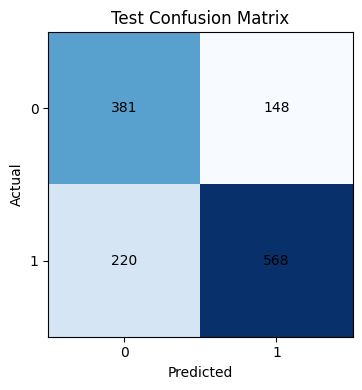

In [8]:
import os
MPLCONFIGDIR = OUTPUT_DIR / '.matplotlib'
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ['MPLCONFIGDIR'] = str(MPLCONFIGDIR)
import matplotlib.pyplot as plt
cm = confusion_matrix(test_df['label'], test_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_title('Test Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.tight_layout()
plt.show()


In [9]:
model_path = MODEL_DIR / "tfidf_logreg_fakehealth_healthfact.joblib"
compat_model_path = MODEL_DIR / "tfidf_logreg.joblib"
metrics_path = OUTPUT_DIR / "tfidf_logreg_metrics.json"
predictions_path = OUTPUT_DIR / "tfidf_logreg_test_predictions.csv"

joblib.dump(pipeline, model_path)
joblib.dump(pipeline, compat_model_path)

test_probabilities = pipeline.predict_proba(test_df[TEXT_COL])

metrics = {
    "model": "TF-IDF + Logistic Regression",
    "text_column": TEXT_COL,
    "train_rows": int(len(train_df)),
    "dev_rows": int(len(dev_df)),
    "test_rows": int(len(test_df)),
    "curated_train_repeat": CURATED_TRAIN_REPEAT,
    "dev_metrics": dev_metrics,
    "test_metrics": test_metrics,
}
metrics_path.write_text(json.dumps(metrics, indent=2), encoding="utf-8")

output_cols = [c for c in ["dataset", "split", "record_id", "text", "model_text", "label"] if c in test_df.columns]
test_output = test_df[output_cols].copy()
test_output["prediction"] = test_pred
test_output["prob_class_0"] = test_probabilities[:, 0]
test_output["prob_class_1"] = test_probabilities[:, 1]
test_output.to_csv(predictions_path, index=False)

print("Saved model to:", model_path)
print("Saved compatibility model to:", compat_model_path)
print("Saved metrics to:", metrics_path)
print("Saved predictions to:", predictions_path)
metrics


Saved model to: C:\Users\ribam\Desktop\Reseach\Dataset\model\tfidf_logreg_fakehealth_healthfact.joblib
Saved compatibility model to: C:\Users\ribam\Desktop\Reseach\Dataset\model\tfidf_logreg.joblib
Saved metrics to: C:\Users\ribam\Desktop\Reseach\Dataset\output\tfidf_logreg_metrics.json
Saved predictions to: C:\Users\ribam\Desktop\Reseach\Dataset\output\tfidf_logreg_test_predictions.csv


{'model': 'TF-IDF + Logistic Regression',
 'text_column': 'model_text',
 'train_rows': 9708,
 'dev_rows': 1338,
 'test_rows': 1317,
 'curated_train_repeat': 4,
 'dev_metrics': {'split': 'dev',
  'accuracy': 0.7227204783258595,
  'precision': 0.7808564231738035,
  'recall': 0.758873929008568,
  'f1': 0.7697082557417753,
  'macro_precision': 0.7093620351163135,
  'macro_recall': 0.7124504002048597,
  'macro_f1': 0.710675724115019,
  'misinformation_precision': 0.6378676470588235,
  'misinformation_recall': 0.6660268714011516,
  'misinformation_f1': 0.6516431924882629,
  'reliable_precision': 0.7808564231738035,
  'reliable_recall': 0.758873929008568,
  'reliable_f1': 0.7697082557417753},
 'test_metrics': {'split': 'test',
  'accuracy': 0.7205770690964313,
  'precision': 0.7932960893854749,
  'recall': 0.7208121827411168,
  'f1': 0.7553191489361702,
  'macro_precision': 0.7136197585030536,
  'macro_recall': 0.720519512920653,
  'macro_f1': 0.7148277160610055,
  'misinformation_precision':

## Next Step

Once this baseline is stable, the next model to compare would be a transformer-based model such as **DistilBERT** or **BioBERT**.
